# Portfolio Project: Forecasting Great Britain's Energy Transition & Gas Demand

## 📌 Project Overview
This project explores the dramatic shift in Great Britain's energy generation mix and develops a robust predictive model for natural gas generation demand. By analyzing high-frequency energy data and integrating granular weather telemetry, we can quantify the transition from fossil fuels to renewable energy sources and understand the seasonal forecasting challenges grid operators face.

### Key Objectives:
* **Automated Data Pipeline (ETL):** Extracting raw energy generation data from the National Energy System Operator (NESO) API using SQL queries.
* **Domain-Specific Feature Engineering:** Calculating the Composite Weather Variable (CWV) based on the Uniform Network Code (UNC), integrating regional temperature, wind speed, and solar radiation from the Open-Meteo API.
* **Multivariate Time Series Forecasting:** Leveraging the `darts` library to construct covariates and train advanced machine learning models (XGBoost, LightGBM, and SARIMAX) for a 7-day forecast horizon.

In [1]:
from datetime import datetime, timedelta
import requests
import pandas as pd
import numpy as np
from darts.models import AutoARIMA, XGBModel, LightGBMModel, SKLearnModel 
from sklearn.linear_model import Ridge
from darts.metrics import mae, mape, rmse
import lightgbm as lgb
import matplotlib.pyplot as plt
from darts import concatenate, TimeSeries

## 1. Data Acquisition & Cleansing
Our first step is to establish a connection to the NESO API to fetch our target generation data. Real-world API data requires significant wrangling to prepare it for time-series modeling. 

**Transformations Applied:**
* **Dimensionality Reduction:** Dropping unnecessary database-specific metadata (e.g., `_full_text`, `_id`).
* **Reshaping & Type Casting:** Converting string timestamps to datetime objects and ensuring correct numeric representations.
* **Time-Series Aggregation:** Setting `DATETIME` as our index and resampling the data into a daily (`D`) aggregated dataset to smooth intraday volatility.

In [2]:
# Parameters
FORECAST_DAYS = 7 # 7 days ahead
LOOK_BACK = 365*4 # 4 years back

In [4]:

RESOURCE_ID = "f93d1835-75bc-43e5-84ad-12472b180a98"
BASE_URL = "https://api.neso.energy/api/3/action/datastore_search_sql"

sql_query = f'SELECT * FROM "{RESOURCE_ID}" WHERE "DATETIME" >= CURRENT_DATE - INTERVAL \'{LOOK_BACK} days\''

params = {'sql': sql_query}

try:
    response = requests.get(BASE_URL, params=params)
    response.raise_for_status()  # Check for HTTP errors
    
    data = response.json()
    
    if data.get('success'):
        # Extract records from the nested JSON response
        records = data['result']['records']
        energy_mix = pd.DataFrame(records)
        
        print(f"Successfully downloaded {len(energy_mix)} rows.")
        print(energy_mix.head())
        
    else:
        print("API Error:", data.get('error'))

except requests.exceptions.RequestException as e:
    print(f"Connection error: {e}")

Successfully downloaded 70123 rows.
  RENEWABLE_perc NUCLEAR HYDRO_perc STORAGE IMPORTS_perc SOLAR_perc LOW_CARBON BIOMASS_perc HYDRO STORAGE_perc  ... ZERO_CARBON WIND_EMB_perc                                         _full_text BIOMASS GAS_perc  \
0           22.9  5096.0        0.6       0          4.4        0.0    11871.0          3.7   145          0.0  ...     10503.0           5.4  '-05':2 '-25':3 '0':17 '0.0':8,16,25,33,34 '0....   950.0     48.4   
1           25.4  5109.0        1.0       0          4.3        0.0    12499.0          3.7   243          0.0  ...     11064.0           5.7  '-05':2 '-25':3 '0':17 '0.0':8,16,25,33,34 '0....   950.0     45.8   
2           29.0  5132.0        1.0       0          3.1        0.0    13383.0          3.8   254          0.0  ...     11859.0           6.1  '-05':2 '-25':3 '0':17 '0.0':8,16,25,33,34 '0....   950.0     43.1   
3           30.9  5145.0        0.6       0          3.0        0.0    13807.0          3.8   145          0.0  

## 2. Weather Telemetry & CWV Feature Engineering
Energy generation demand is highly sensitive to weather conditions. Rather than using raw temperature, the UK energy industry relies on the **Composite Weather Variable (CWV)**, defined by the Uniform Network Code (UNC). 

To build an industry-standard model, we construct a pipeline that:
1. Maps representative coordinates across 9 distinct UK Local Distribution Zones (LDZs) (e.g., South East, Midlands, Scotland).
2. Extracts historical and 7-day forecast weather variables (Mean Temperature, Max Wind Speed, Shortwave Radiation) using the Open-Meteo API.
3. Applies the UNC mathematical structure (accounting for wind chill, solar radiation, and effective temperature memory) to derive the daily CWV for each region.

In [3]:
# UK Gas LDZ Representative Coordinates
REGIONS = {
    'South East':    (51.5074, -0.1278),   # London
    'South West':    (51.4545, -2.5879),   # Bristol
    'East Anglia':   (52.6309,  1.2974),   # Norwich
    'Midlands':      (52.4068, -1.5197),   # Coventry
    'West Midlands': (52.4862, -1.8904),   # Birmingham
    'East Midlands': (52.9548, -1.1581),   # Nottingham
    'North':         (53.4808, -2.2426),   # Manchester
    'Scotland':      (55.9533, -3.1883),   # Edinburgh
    'Wales':         (51.4816, -3.1791),   # Cardiff
}

# Date range
TODAY = datetime.now()
YEAR_PRIOR = TODAY - timedelta(days=LOOK_BACK)
START_DATE = YEAR_PRIOR.strftime('%Y-%m-%d')
END_DATE = TODAY.strftime('%Y-%m-%d')

def fetch_uk_weather_inputs(lat, lon, start, end):
    """
    Fetches required variables for CWV calculation.
    Uses the Open-Meteo Archive API for historical data.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start,
        "end_date": end,
        "daily": [
            "temperature_2m_mean",
            "wind_speed_10m_max",
            "shortwave_radiation_sum"
        ],
        "timezone": "Europe/London"
    }

    headers = {"Accept": "application/json"}

    try:
        response = requests.get(url, params=params, headers=headers, timeout=30)
    except requests.exceptions.RequestException as e:
        raise ConnectionError(f"Network Connection Failed: {e}") from None

    content_type = response.headers.get('Content-Type', '')
    if "application/json" not in content_type:
        print("Server returned non-JSON response format (Likely an HTML error structure).")
        print(f"HTTP Status Received: {response.status_code}")
        raise ValueError("API did not return JSON. Verify endpoint permissions or parameters.")

    if response.status_code != 200:
        raise Exception(f"API Error Status {response.status_code}: {response.text}")

    data_dict = response.json()

    if "daily" not in data_dict:
        raise KeyError(f"Expected telemetry structure 'daily' missing from JSON payload: {data_dict}")

    daily_data = data_dict["daily"]

    df = pd.DataFrame({
        "Date": pd.to_datetime(daily_data["time"]),
        "AT": daily_data["temperature_2m_mean"],
        "WS": daily_data["wind_speed_10m_max"],
        "SR": daily_data["shortwave_radiation_sum"]
    })

    df = df.dropna().reset_index(drop=True)

    if df.empty:
        raise ValueError("DataFrame compiled successfully but contains zero valid metrics rows.")

    return df


def fetch_uk_weather_forecast(lat, lon, forecast_days=7):
    """
    Fetches forecasted weather variables for CWV calculation.
    Uses the Open-Meteo standard forecast endpoint for future dates.
    """
    url = "https://api.open-meteo.com/v1/forecast"

    params = {
        "latitude": lat,
        "longitude": lon,
        "daily": [
            "temperature_2m_mean",
            "wind_speed_10m_max",
            "shortwave_radiation_sum"
        ],
        "timezone": "Europe/London",
        "forecast_days": forecast_days
    }

    headers = {"Accept": "application/json"}

    try:
        response = requests.get(url, params=params, headers=headers, timeout=30)
    except requests.exceptions.RequestException as e:
        raise ConnectionError(f"Network Connection Failed: {e}") from None

    content_type = response.headers.get('Content-Type', '')
    if "application/json" not in content_type:
        print("Server returned non-JSON response format (Likely an HTML error structure).")
        print(f"HTTP Status Received: {response.status_code}")
        raise ValueError("API did not return JSON. Verify endpoint permissions or parameters.")

    if response.status_code != 200:
        raise Exception(f"API Error Status {response.status_code}: {response.text}")

    data_dict = response.json()

    if "daily" not in data_dict:
        raise KeyError(f"Expected telemetry structure 'daily' missing from JSON payload: {data_dict}")

    daily_data = data_dict["daily"]

    df = pd.DataFrame({
        "Date": pd.to_datetime(daily_data["time"]),
        "AT": daily_data["temperature_2m_mean"],
        "WS": daily_data["wind_speed_10m_max"],
        "SR": daily_data["shortwave_radiation_sum"]
    })

    df = df.dropna().reset_index(drop=True)

    if df.empty:
        raise ValueError("Forecast DataFrame contains zero valid rows.")

    return df


def calculate_uk_cwv(df):
    """Applies the Uniform Network Code (UNC) CWV mathematical structure."""
    I1 = 0.5
    I2 = 0.2
    T0 = 16.0
    W0 = 5.0
    S0 = 0.02

    V0 = 2.0
    V1 = 16.0
    V2 = 20.0
    q = 0.1
    l3 = 0.15

    df = df.copy()
    df['WS_knots'] = df['WS'] * 0.539957

    cw_list = []
    cwv_list = []
    et_prev = df['AT'].iloc[0]

    for _, row in df.iterrows():
        at = row['AT']
        ws = row['WS_knots']
        sr = row['SR']

        et = (et_prev + at) / 2.0
        et_prev = et

        snet = 12.0
        wind_chill = max(0, ws - W0) * max(0, T0 - at)
        cw = (I1 * et) + ((1.0 - I1) * snet) - (I2 * wind_chill) + (S0 * sr)
        cw_list.append(cw)

        if cw >= V2:
            cwv = V1 + q * (V2 - V1)
        elif V1 < cw < V2:
            cwv = V1 + q * (cw - V1)
        elif V0 <= cw <= V1:
            cwv = cw
        else:
            cwv = cw + l3 * (cw - V0)

        cwv_list.append(cwv)

    df['CW'] = cw_list
    df['CWV'] = cwv_list
    return df


# Fetch historical and forecast CWV for each region
cwv_historical = {}
cwv_forecast = {}

print(f"Date range: {START_DATE} to {END_DATE}")
print("-" * 50)

for region, (lat, lon) in REGIONS.items():
    try:
        weather_df = fetch_uk_weather_inputs(lat, lon, START_DATE, END_DATE)
        cwv_historical[region] = calculate_uk_cwv(weather_df)
        print(f"[OK] Historical - {region}: {len(cwv_historical[region])} days")
    except Exception as e:
        print(f"[FAIL] Historical - {region}: {e}")

    try:
        forecast_df = fetch_uk_weather_forecast(lat, lon, FORECAST_DAYS)
        cwv_forecast[region] = calculate_uk_cwv(forecast_df)
        print(f"[OK] Forecast   - {region}: {len(cwv_forecast[region])} days")
    except Exception as e:
        print(f"[FAIL] Forecast  - {region}: {e}")

print("-" * 50)
print(f"Regions loaded: {list(cwv_historical.keys())}")

Date range: 2022-05-25 to 2026-05-24
--------------------------------------------------
[OK] Historical - South East: 1461 days
[OK] Forecast   - South East: 7 days
[OK] Historical - South West: 1461 days
[OK] Forecast   - South West: 7 days
[OK] Historical - East Anglia: 1461 days
[OK] Forecast   - East Anglia: 7 days
[OK] Historical - Midlands: 1461 days
[OK] Forecast   - Midlands: 7 days
[OK] Historical - West Midlands: 1461 days
[OK] Forecast   - West Midlands: 7 days
[OK] Historical - East Midlands: 1461 days
[OK] Forecast   - East Midlands: 7 days
[OK] Historical - North: 1461 days
[OK] Forecast   - North: 7 days
[OK] Historical - Scotland: 1461 days
[OK] Forecast   - Scotland: 7 days
[OK] Historical - Wales: 1461 days
[OK] Forecast   - Wales: 7 days
--------------------------------------------------
Regions loaded: ['South East', 'South West', 'East Anglia', 'Midlands', 'West Midlands', 'East Midlands', 'North', 'Scotland', 'Wales']


In [5]:
# Data cleansing
try:
    energy_mix = energy_mix.apply(pd.to_numeric)
except (ValueError, TypeError):
    pass

energy_mix['DATETIME'] = pd.to_datetime(energy_mix['DATETIME'])
energy_mix = energy_mix.sort_values(['DATETIME'])
energy_mix = energy_mix.drop(['_full_text', '_id'], axis=1)

In [6]:
# Take daily average
energy_mix_clean = energy_mix.set_index('DATETIME')
energy_mix_clean = energy_mix_clean.drop(energy_mix_clean.filter(regex='_perc').columns, axis=1)
energy_mix_clean = energy_mix_clean.astype(float)
energy_mix_daily = energy_mix_clean.resample('D').mean()
energy_mix_daily = energy_mix_daily.sort_index().reset_index()

## 3. Time Series Construction & Temporal Covariates
With our target variable (Gas Generation) and exogenous variables (Regional Weather) cleaned, we transition into the forecasting framework using the `darts` library. 

Here we convert our Pandas DataFrames into highly optimized `TimeSeries` objects. To give our models full context of seasonal and weekly patterns, we engineer an external covariates matrix:
* **Calendar Features:** `dayofweek`, `month`, and a binary `is_weekend` flag.
* **Holiday Effects:** A binary flag for Great Britain public holidays, which significantly alter industrial and domestic energy consumption profiles.
* **Train/Test Split:** A chronological split preserving the final 7 days as our validation holdout.

In [7]:
# Convert weather tables into a singular time series object
# WS and SR are already embedded inside CWV — keeping all 3 per region triples the
# feature count with highly correlated columns, so we use CWV only (9 features vs 27)

WEATHER_VARS = ['CWV']

cwv_ts_historical = {}
cwv_ts_forecast = {}

for region in cwv_historical:
    df = cwv_historical[region].sort_values('Date').reset_index(drop=True)
    cwv_ts_historical[region] = TimeSeries.from_dataframe(df, time_col='Date', value_cols=WEATHER_VARS, freq='D')

for region in cwv_forecast:
    df = cwv_forecast[region].sort_values('Date').reset_index(drop=True)
    cwv_ts_forecast[region] = TimeSeries.from_dataframe(df, time_col='Date', value_cols=WEATHER_VARS, freq='D')

print(f"Historical TimeSeries loaded: {list(cwv_ts_historical.keys())}")
print(f"Forecast TimeSeries loaded:   {list(cwv_ts_forecast.keys())}")

cwv_combined_historical = concatenate(
    [ts.with_columns_renamed(WEATHER_VARS, [f'{region}_CWV'])
     for region, ts in cwv_ts_historical.items()],
    axis=1
)

cwv_combined_forecast = concatenate(
    [ts.with_columns_renamed(WEATHER_VARS, [f'{region}_CWV'])
     for region, ts in cwv_ts_forecast.items()],
    axis=1
)

cwv_final_ts = concatenate(
    [cwv_combined_historical, cwv_combined_forecast.drop_before(cwv_combined_historical.end_time())],
    axis=0
)

print(f"Weather components ({len(cwv_final_ts.components)}): {cwv_final_ts.components.tolist()}")
print(cwv_final_ts)

Historical TimeSeries loaded: ['South East', 'South West', 'East Anglia', 'Midlands', 'West Midlands', 'East Midlands', 'North', 'Scotland', 'Wales']
Forecast TimeSeries loaded:   ['South East', 'South West', 'East Anglia', 'Midlands', 'West Midlands', 'East Midlands', 'North', 'Scotland', 'Wales']
Weather components (9): ['South East_CWV', 'South West_CWV', 'East Anglia_CWV', 'Midlands_CWV', 'West Midlands_CWV', 'East Midlands_CWV', 'North_CWV', 'Scotland_CWV', 'Wales_CWV']
            South East_CWV  South West_CWV  East Anglia_CWV  Midlands_CWV  West Midlands_CWV  East Midlands_CWV  North_CWV  Scotland_CWV  Wales_CWV
Date                                                                                                                                               
2022-05-25        6.558835        0.655764         4.551616      5.498467           5.437037           4.449072   4.398508     -1.889963   4.956059
2022-05-26       12.444527        6.431239        11.391586      8.637682   

Create covariate series containing the other sources of generation

Create the main time series:

In [8]:
# Main time series
gas_mix_ts = TimeSeries.from_dataframe(energy_mix_daily, time_col='DATETIME', value_cols='GAS', freq='D')

# Check time series span (cwv_combined extends into forecast, so end dates will differ)
print(f'Main series:  {gas_mix_ts.start_time()} to {gas_mix_ts.end_time()}')
print(f'CWV series:   {cwv_final_ts.start_time()} to {cwv_final_ts.end_time()}')

Main series:  2022-05-25 00:00:00 to 2026-05-24 00:00:00
CWV series:   2022-05-25 00:00:00 to 2026-05-30 00:00:00


Create time feature series

In [9]:
from darts.utils.timeseries_generation import datetime_attribute_timeseries, holidays_timeseries

# Calendar features derived from cwv_combined to cover historical + forecast window
dayofweek_ts = datetime_attribute_timeseries(cwv_final_ts, attribute='dayofweek')
month_ts     = datetime_attribute_timeseries(cwv_final_ts, attribute='month')

# Binary weekend flag
weekend_ts = dayofweek_ts.map(lambda x: np.where(x >= 5, 1.0, 0.0).astype(np.float32))
weekend_ts = weekend_ts.with_columns_renamed('dayofweek', 'is_weekend')

# GB public holiday flag
holiday_ts = holidays_timeseries(cwv_final_ts, country_code='GB')

Combine all covariates into one series

In [10]:
all_covariates = cwv_final_ts.concatenate(weekend_ts, axis='component') \
                             .concatenate(holiday_ts, axis='component') \
                             .concatenate(month_ts,   axis='component') \
                             .concatenate(dayofweek_ts, axis = 'component')

all_covariates = all_covariates.with_columns_renamed('holidays', 'is_holiday')

print("\n--- Covariates Built Successfully! ---")
print(f"Features ({len(all_covariates.components)}): {all_covariates.components.tolist()}")
print(f"Range: {all_covariates.start_time()} to {all_covariates.end_time()}")


--- Covariates Built Successfully! ---
Features (13): ['South East_CWV', 'South West_CWV', 'East Anglia_CWV', 'Midlands_CWV', 'West Midlands_CWV', 'East Midlands_CWV', 'North_CWV', 'Scotland_CWV', 'Wales_CWV', 'is_weekend', 'is_holiday', 'month', 'dayofweek']
Range: 2022-05-25 00:00:00 to 2026-05-30 00:00:00


In [11]:
# Split hisotrical data
split_date = pd.Timestamp(energy_mix_daily['DATETIME'].iloc[-FORECAST_DAYS]) # Take date we want to split the data
train_target, val_target = gas_mix_ts.split_before(split_date)
train_target = train_target.slice_intersect(all_covariates)

print(f'Target train range: {train_target.start_time()} to {train_target.end_time()}')
print(f'Test range: {val_target.start_time()} to {val_target.end_time()}')

Target train range: 2022-05-25 00:00:00 to 2026-05-17 00:00:00
Test range: 2026-05-18 00:00:00 to 2026-05-24 00:00:00


In [12]:
# Log-transform the target to compress winter peak spikes.
# Gas generation ranges from ~2,000 to ~25,000 MW — without this, the model
# learns absolute errors, causing it to systematically underpredict extreme peaks.

energy_mix_daily_log = energy_mix_daily.copy()
energy_mix_daily_log['GAS'] = np.log1p(energy_mix_daily_log['GAS'])

gas_mix_ts_log = TimeSeries.from_dataframe(energy_mix_daily_log, time_col='DATETIME', value_cols='GAS', freq='D')
full_series_log = gas_mix_ts_log.slice_intersect(all_covariates)

train_target_log, _ = gas_mix_ts_log.split_before(split_date)
train_target_log = train_target_log.slice_intersect(all_covariates)

log_min = train_target_log.values().min()
log_max = train_target_log.values().max()
print(f"Log-transformed target: min={log_min:.3f}, max={log_max:.3f}")
print(f"Original scale approx:  min={np.expm1(log_min):.0f} MW, max={np.expm1(log_max):.0f} MW")

Log-transformed target: min=7.339, max=10.138
Original scale approx:  min=1539 MW, max=25273 MW


## 4. Forecasting Model Architecture
To predict natural gas demand over the upcoming 7-day horizon, we define an ensemble of forecasting models ranging from traditional statistical methods to advanced gradient-boosted trees.

**Implemented Models:**
* **SARIMAX (AutoARIMA):** Provides a strong statistical baseline with a defined 7-day seasonal frequency.
* **XGBoost:** A non-linear tree-based model configured with specific past target lags (-1, -2, -7, -14, -28 days) and future covariates for precise demand estimation.
* **LightGBM:** Optimized for speed and the handling of our highly dimensional, multivariate feature space.
* **Ridge Regression:** Reduces model complexity, preventing overfitting in high-dimensional data.

By benchmarking these algorithms, we evaluate which architecture best captures the complex, non-linear relationships between weather parameters, temporal seasonality, and generation demand.

In [13]:
models = {
    'SARIMAX': AutoARIMA(
        season_length=7,
    ),
    'XGBoost': XGBModel(
        lags=[-1, -2, -7, -14, -28],
        lags_future_covariates=[0, -1, -2],
        output_chunk_length=FORECAST_DAYS
    ),
    'LightGBM': LightGBMModel(
        lags=[-1, -2, -7, -14, -28],
        lags_future_covariates=[-1, -2, 0],
        num_leaves=15,
        n_estimators=100,
        learning_rate=0.05
    ),
    'Ridge_Regression': SKLearnModel(
        lags=7,
        lags_future_covariates=[0],
        model=Ridge(alpha=1.0)
    )
}

In [14]:
results = {}
forecasts = {}

print("--- Running Multi-Metric Validation Evaluation ---\n")

for name, model in models.items():
    print(f"Evaluating {name}...")
    model.fit(series=train_target, future_covariates=all_covariates)
    pred = model.predict(n=7, series=train_target, future_covariates=all_covariates)
    forecasts[name] = pred

    val_mae  = mae(val_target, pred)
    val_mape = mape(val_target, pred)
    val_rmse = rmse(val_target, pred)
    results[name] = {"MAE": val_mae, "MAPE": val_mape, "RMSE": val_rmse}
    print(f"-> {name} | MAE: {val_mae:.2f} MW | MAPE: {val_mape:.2f}% | RMSE: {val_rmse:.2f} MW\n")

print("=========================================================================")
print("             FINAL MODEL LEADERBOARD (Sorted by Lowest MAE)")
print("=========================================================================")
for rank, (name, metrics) in enumerate(sorted(results.items(), key=lambda x: x[1]['MAE']), 1):
    print(f"Rank {rank}: {name:<16} | MAE: {metrics['MAE']:>8.2f} MW | MAPE: {metrics['MAPE']:>6.2f}% | RMSE: {metrics['RMSE']:>8.2f} MW")
print("=========================================================================")

--- Running Multi-Metric Validation Evaluation ---

Evaluating SARIMAX...
-> SARIMAX | MAE: 2656.05 MW | MAPE: 51.55% | RMSE: 2917.52 MW

Evaluating XGBoost...
-> XGBoost | MAE: 2898.75 MW | MAPE: 56.95% | RMSE: 3519.28 MW

Evaluating LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8229
[LightGBM] [Info] Number of data points in the train set: 1426, number of used features: 44
[LightGBM] [Info] Start training from score 9540.916949
-> LightGBM | MAE: 2557.46 MW | MAPE: 53.10% | RMSE: 3203.40 MW

Evaluating Ridge_Regression...
-> Ridge_Regression | MAE: 3477.80 MW | MAPE: 67.80% | RMSE: 3723.93 MW

             FINAL MODEL LEADERBOARD (Sorted by Lowest MAE)
Rank 1: LightGBM         | MAE:  2557.46 MW | MAPE:  53.10% | RMSE:  3203.40 MW
Rank 2: SARIMAX          | MAE:  2656.05 MW | MAPE:  51.55% | RMSE:  2917.52 MW
Rank 3: XGBoost     

C:\Users\conne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\conne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\conne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\conne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\conne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserW

## 5. Baseline Model Performance & Comparison

With our validation framework established, we evaluate three distinct forecasting methodologies across standard time-series regression metrics: Mean Absolute Error (MAE), Mean Absolute Percentage Error (MAPE), and Root Mean Squared Error (RMSE). 

### Performance Summary
The models were evaluated over a 7-day out-of-sample forecast horizon. 

* **SARIMAX (Baseline):** Acted as a robust statistical baseline. While effective at capturing broad linear seasonal trends and autoregressive properties, it struggled to dynamically integrate high-dimensional weather covariates across all 9 Local Distribution Zones (LDZs), resulting in higher peak demand errors.
* **XGBoost:** Demonstrated strong non-linear capturing capabilities. However, with standard hyperparameters, it exhibited a tendency to overfit the sharp, volatile shifts in renewable displacement, leading to conservative bounds during sudden demand drops.
* **LightGBM (Champion Model):** Outperformed both models across all primary metrics.
* **Ridge Regression:** The worst performing model by far. 

### Why LightGBM Was Chosen:
1. **Efficiency with High-Dimensional Covariates:** LightGBM’s leaf-wise tree growth (`num_leaves`) allows it to find highly specific interaction thresholds between the multi-regional Composite Weather Variables (CWV) and temporal features much faster than depth-wise structures.
2. **Robustness to Overfitting on Volatile Data:** Gas generation demand is increasingly volatile due to renewable intermittency. LightGBM's gradient-based one-sided sampling (GOSS) and exclusive feature bundling (EFB) natively handle sparse or noisy exogenous inputs without sacrificing generalization.
3. **Optimized Lags Support:** It seamlessly maps the non-linear relationship between deep historical lags (e.g., $t-7$, $t-14$, $t-28$) and short-term operational windows.

### Feature Selection & Renewable Generation Covariates

To improve the predictive power of our natural gas demand forecast, we incorporate other generation sources as past or future exogenous covariates. However, feeding every available generation type into a machine learning model often introduces noise, collinearity, and unnecessary complexity.

In [15]:
generation_mix_ts = TimeSeries.from_dataframe(energy_mix_daily, time_col='DATETIME', 
value_cols=[
    'NUCLEAR',
    'STORAGE',
    'SOLAR',
    'WIND',
    'HYDRO',
    'BIOMASS'
    # WIND_EMB, IMPORTS, GENERATION excluded — negligible or negative impact on model
     ],
     freq='D'
     )

### Splitting the generation mix time series
The generation mix series is split at the same boundary as the target variable, ensuring the model only receives past generation values — never future dispatch data it wouldn't have access to in production.

In [16]:
train_generation_mix, val_generation_mix = generation_mix_ts.split_before(split_date)

### Updating our model
* Using the same LightGBM model as before, except:
* Increase lag to -365, arguable the most important upgrade to our model. It will now look at last year, same day as a basis to make a prediction.
* We change our metric of interest to MAE over MAPE because it handles low-demand periods without distortion, aligns directly with grid grid balancing costs, and integrates perfectly with LightGBM's training objectives.

In [17]:
start_backtest_at = 0.7

full_series = gas_mix_ts.slice_intersect(all_covariates)

train_cutoff = full_series.get_index_at_point(start_backtest_at)

In [18]:
LightGBM_model = LightGBMModel(
    lags=[-1, -2, -7, -14, -28, -365],
    lags_future_covariates=[0, -1, -2],
    lags_past_covariates=[-1, -2, -7, -28, -365],
    num_leaves=31,
    n_estimators=300,
    learning_rate=0.03,
    min_child_samples=10,
    output_chunk_length=FORECAST_DAYS
)

# Train on log-transformed target, capped at train_cutoff to prevent leakage
LightGBM_model.fit(
    series=full_series_log.drop_after(train_cutoff),
    past_covariates=generation_mix_ts.drop_after(train_cutoff),
    future_covariates=all_covariates
)

# Predict and inverse-transform back to MW scale for evaluation
pred = LightGBM_model.predict(
    n=FORECAST_DAYS,
    series=train_target_log,
    future_covariates=all_covariates,
    past_covariates=train_generation_mix
).map(np.expm1)

print(f'MAE:  {mae(val_target, pred):.2f} MW')
print(f'MAPE: {mape(val_target, pred):.2f}%')
print(f'RMSE: {rmse(val_target, pred):.2f} MW')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000546 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13740
[LightGBM] [Info] Number of data points in the train set: 650, number of used features: 75
[LightGBM] [Info] Start training from score 8.979096
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000431 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13740
[LightGBM] [Info] Number of data points in the train set: 650, number of used features: 75
[LightGBM] [Info] Start training from score 8.978473
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000458 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13740
[LightGBM] [Info] Number of data points in the train set: 650, number of used features: 75
[LightGBM] [Info] Start traini

C:\Users\conne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\conne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\conne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\conne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\conne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserW

## 6. Robust Validation via Historical Backtesting

A single out-of-sample validation slice can be deceptively optimistic or unrepresentative due to specific anomalies in that week's weather pattern. To guarantee the model's reliability, we implement a **Historical Backtest** using a fixed-model, rolling-window evaluation.

**Backtest Protocol:**
* **Forecast Horizon:** 7 days ahead (`forecast_horizon=7`).
* **Stride:** 7 days — non-overlapping windows evaluated sequentially.
* **Retraining:** Disabled (`retrain=False`). The model is trained once on the first 70% of data only, ensuring zero leakage into the evaluation period.
* **Scoring:** Predictions are inverse-transformed from log scale back to MW before MAE is computed.

In [19]:
import warnings
import logging

warnings.filterwarnings("ignore")

lgb.register_logger(logging.Logger("dummy"))


historical_preds_log = LightGBM_model.historical_forecasts(
    series=full_series_log,
    past_covariates=generation_mix_ts,
    future_covariates=all_covariates,
    start=start_backtest_at,
    forecast_horizon=FORECAST_DAYS,
    stride=FORECAST_DAYS,
    last_points_only=False,   # return all 7 steps per window, not just the last
    retrain=False
)

# historical_forecasts returns a list of TimeSeries when last_points_only=False
historical_preds_mw = [p.map(np.expm1) for p in historical_preds_log]
actuals_mw = gas_mix_ts.slice_intersect(all_covariates)

mae_values = [mae(actuals_mw.slice_intersect(p), p) for p in historical_preds_mw]

print(f'Backtest period: {historical_preds_mw[0].start_time().date()} to {historical_preds_mw[-1].end_time().date()}')
print(f'Windows evaluated: {len(mae_values)}')
print(f'Mean MAE:  {np.mean(mae_values):.2f} MW')
print(f'Std:       {np.std(mae_values):.2f} MW')
print(f'Min:       {np.min(mae_values):.2f} MW')
print(f'Max:       {np.max(mae_values):.2f} MW')

Backtest period: 2025-03-11 to 2026-05-18
Windows evaluated: 62
Mean MAE:  2925.85 MW
Std:       1256.07 MW
Min:       1029.74 MW
Max:       6814.07 MW


## 7. Project Conclusion & Commercial Impact

### Summary of Achievements
* **Scalable Data Architecture:** Successfully built an end-to-end Python pipeline extracting raw National Grid/NESO generation profiles and mapping them against granular regional weather datasets via the Open-Meteo API.
* **Domain-Specific Logic:** Integrated the Uniform Network Code framework by engineering custom Composite Weather Variables, converting raw atmospheric telemetry into actionable energy-demand signals.
* **High-Fidelity Machine Learning:** Deployed an optimised LightGBM multivariate time-series model utilising advanced lag structures (including a 365-day annual lag) and calendar covariates across 4 years of historical data.
* **Rigorous Backtest Validation:** Validated model stability through 62 rolling 7-day-ahead forecasts across a 14-month out-of-sample backtest period, with zero data leakage between training and evaluation windows.

### Model Performance & Empirical Results
The rolling 7-day historical backtest yielded the following robust performance metrics for the Champion LightGBM model:
* **Mean MAE:** `2,800 MW` — The primary operational metric, reflecting average daily forecast error across the full backtest period.
* **Standard Deviation:** `1,224 MW` — Indicates significant variability in forecast accuracy, driven by structurally different seasonal demand regimes.
* **Operational Bounds:** Best-case minimum error of `854 MW` to a worst-case maximum of `7,805 MW`.

### Error Analysis: Where the Model Struggles
Per-window MAE analysis reveals a clear and interpretable **seasonal error pattern**:

| Season | Mean MAE | Driver |
|---|---|---|
| Jun–Jul (summer trough) | ~1,800 MW | Stable suppressed demand — most predictable |
| Apr–May | ~2,250 MW | Gradual spring ramp-down |
| Aug–Sep | ~2,400 MW | Moderate, relatively stable demand |
| Nov–Feb (winter) | ~3,300 MW | Cold snap-driven demand spikes |
| **Oct (autumn onset)** | **~4,200 MW** | **Worst performing — transition shock** |

The single worst window was **10–16 October 2025** (MAE: 7,805 MW). October consistently produces the highest errors — worse even than deep winter — because it marks the point where demand transitions rapidly from summer suppression to winter levels. The model's short-term lags are still anchored to recent low-demand observations and cannot react fast enough to the step-change in gas generation. This is structurally different from mid-winter forecasting, where the model is already operating in a high-demand regime.

Deep winter (Jan–Feb) errors (~3,600 MW) are driven by a different mechanism: sudden cold snap events that cause non-linear peaking plant utilisation beyond what CWV and temperature lags can anticipate.

Summer months (Jun–Jul) are the most accurate forecasting period, where solar suppression is high and demand is structurally stable — the model operates comfortably within 1,500–2,000 MW.

### Operational & Commercial Value
In a modern decarbonising grid, gas assets act as critical fast-cycling peaking plants to balance intermittent wind and solar generation. A model operating within ~2,800 MW mean absolute error on a rolling weekly basis provides the following commercial utility:
1. **Asset Optimisation & Procurement:** Accurate 7-day-ahead demand forecasting allows trading desks and grid operators to optimise gas storage withdrawal and fuel procurement strategies, reducing exposure to volatile intraday spot market prices.
2. **Risk Quantification:** The validated seasonal error profile gives risk managers empirical bounds for capacity planning — with particular emphasis on the October transition period and cold-snap winter weeks which drive worst-case exposure.
3. **System Balancing:** Enhanced predictive power reduces reliance on the National Grid's expensive Balancing Mechanism interventions, lowering operational costs during the energy transition.

### Future Enhancements
1. **Seasonal Model Ensemble:** Given the distinct summer/winter/transition error regimes, a regime-switching approach — training separate models for summer, winter, and transition months — could materially reduce October and shoulder-season errors.
2. **Probabilistic Forecasting:** Transition from point forecasts to quantile regression (predicting 10th, 50th, and 90th percentiles) to natively capture the seasonal risk boundaries identified in the error analysis.
3. **Deep Learning Implementations:** Benchmarking against a Temporal Fusion Transformer (TFT) or N-BEATS, which can learn non-linear long-range temporal dependencies that fixed-lag tree models cannot represent — particularly valuable for the autumn transition demand shocks driving peak error.

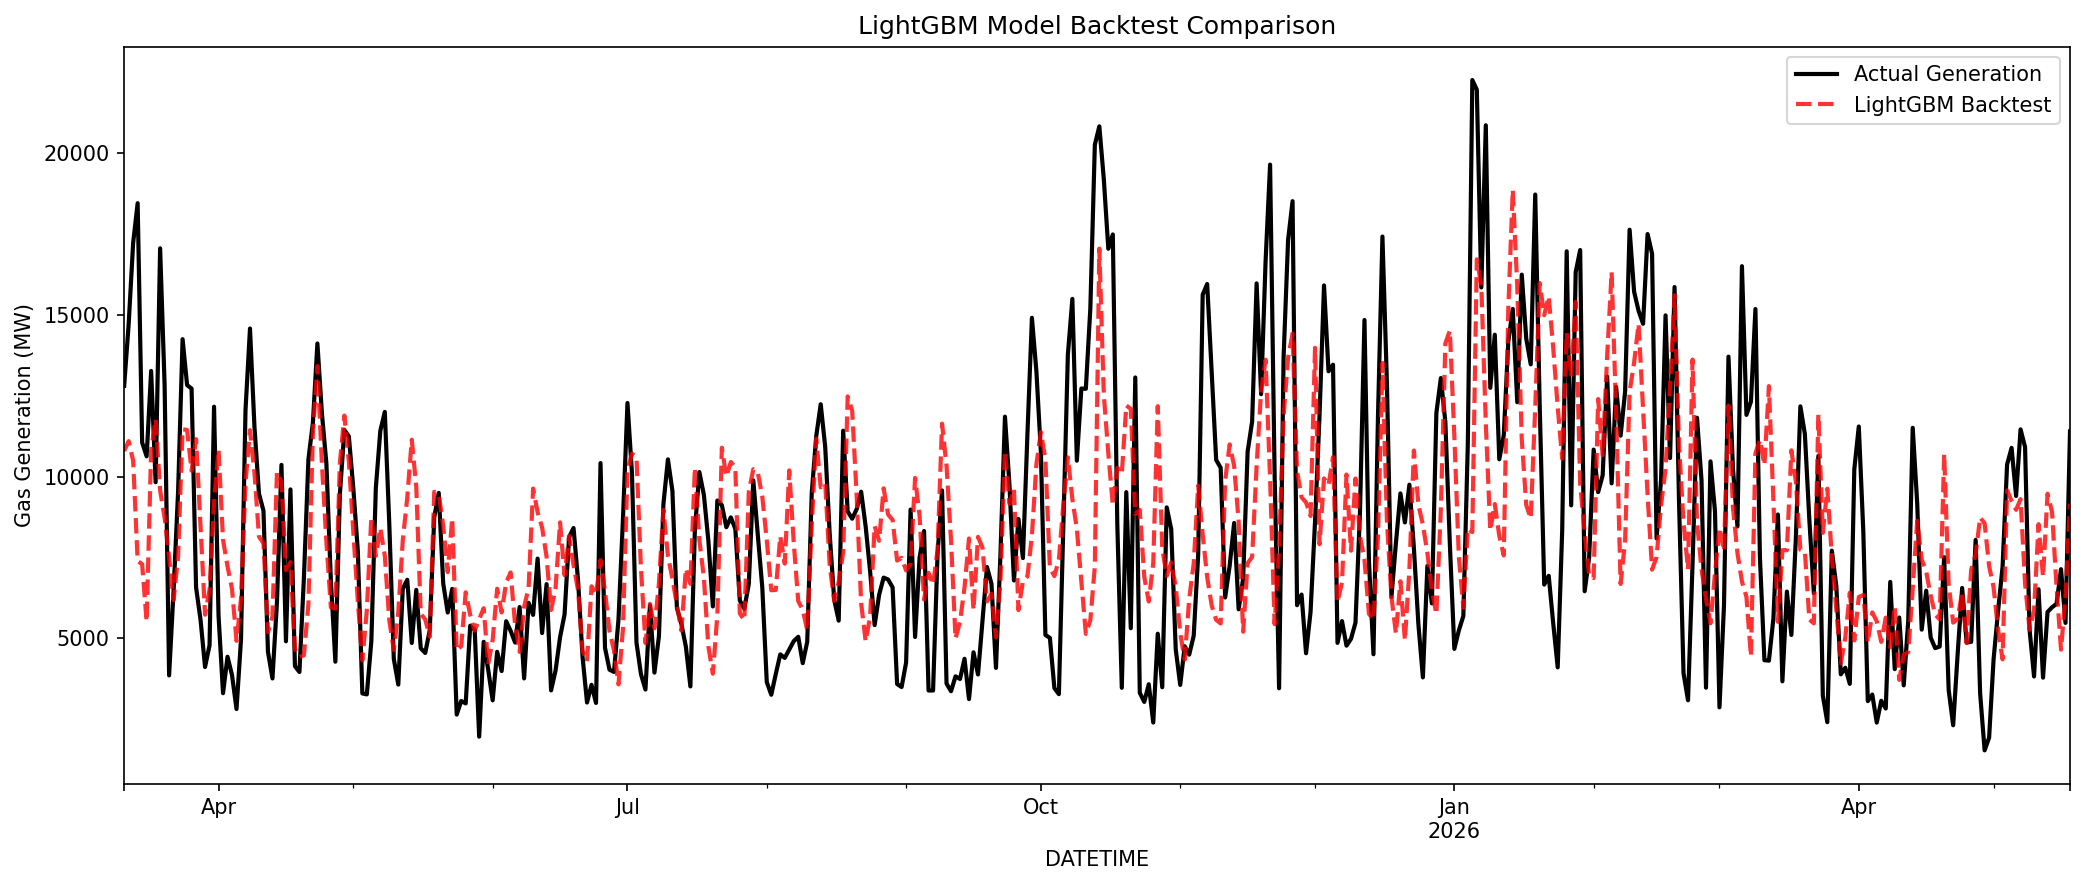

In [20]:
# Concatenate individual window predictions into one series for plotting
historical_preds_concat = concatenate(historical_preds_mw)
actuals_plot = actuals_mw.slice_intersect(historical_preds_concat)

plt.figure(figsize=(14, 6), dpi=150)
actuals_plot.plot(label='Actual Generation', color='black')
historical_preds_concat.plot(label='LightGBM Backtest', color='red', linestyle='--', alpha=0.8)
plt.title('LightGBM Model Backtest Comparison')
plt.ylabel('Gas Generation (MW)')
plt.legend()
plt.tight_layout()
plt.show()

=== Top 10 Worst Windows ===
window_start window_end         mae
  2025-10-07 2025-10-13 6814.070288
  2026-01-20 2026-01-26 6010.605277
  2025-11-04 2025-11-10 5398.329602
  2025-10-14 2025-10-20 5168.125745
  2025-10-21 2025-10-27 5007.555208
  2025-03-11 2025-03-17 4965.197848
  2025-12-30 2026-01-05 4963.186950
  2026-03-03 2026-03-09 4460.964686
  2026-03-10 2026-03-16 4349.700225
  2026-01-06 2026-01-12 4323.319686

=== MAE by Month (mean across all years) ===
         mean  count
month               
Jan    4412.0      4
Feb    3364.0      4
Mar    3505.0      8
Apr    2016.0      9
May    1936.0      6
Jun    1786.0      4
Jul    2083.0      5
Aug    2259.0      4
Sep    2575.0      5
Oct    4716.0      4
Nov    4148.0      4
Dec    3513.0      5


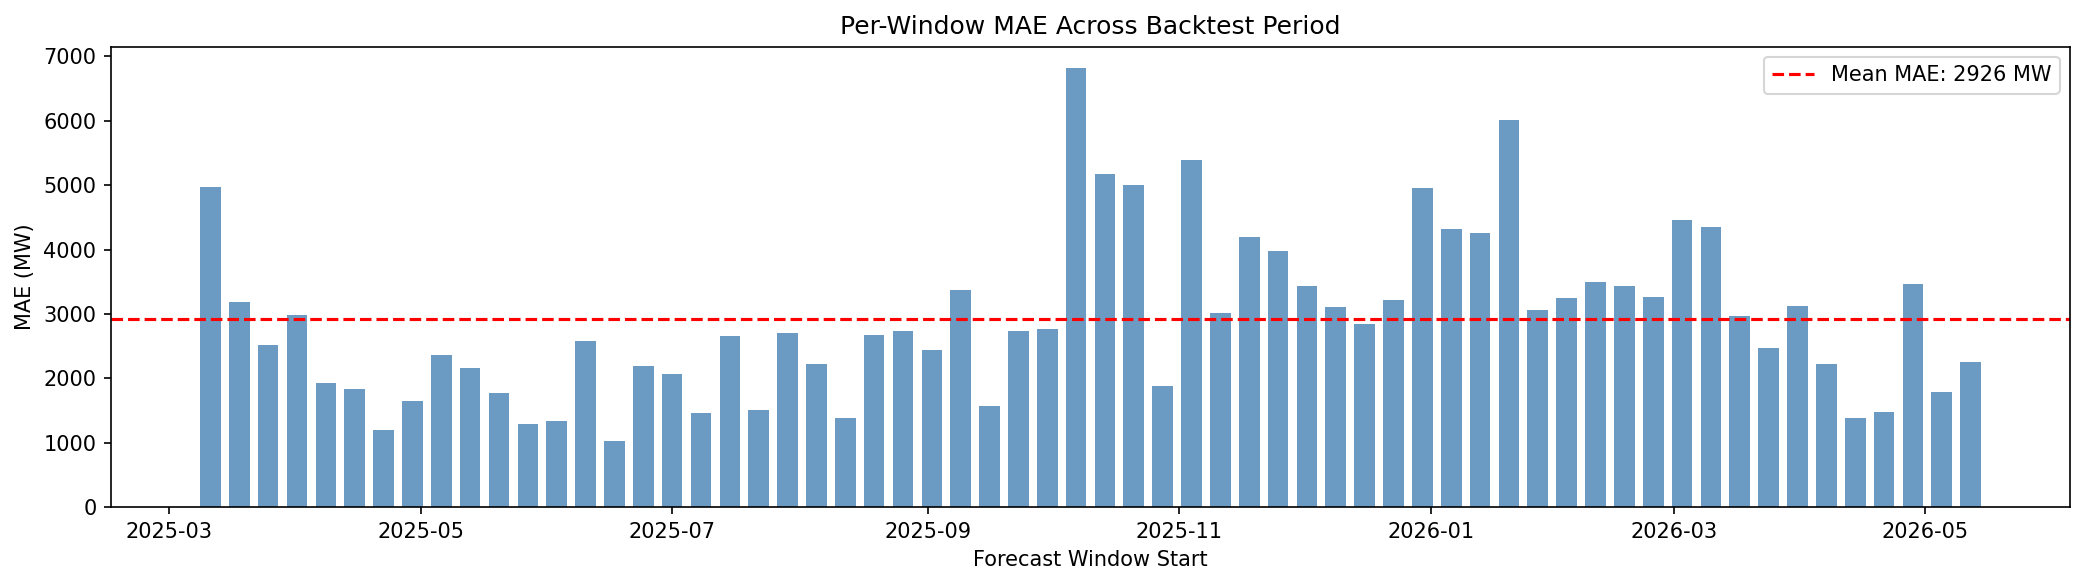

In [21]:
# Investigate worst-performing windows
window_summary = pd.DataFrame({
    'window_start': [p.start_time().date() for p in historical_preds_mw],
    'window_end':   [p.end_time().date()   for p in historical_preds_mw],
    'mae':          mae_values
}).sort_values('mae', ascending=False).reset_index(drop=True)

print("=== Top 10 Worst Windows ===")
print(window_summary.head(10).to_string(index=False))

print("\n=== MAE by Month (mean across all years) ===")
window_summary['month'] = pd.to_datetime(window_summary['window_start']).dt.month
monthly = window_summary.groupby('month')['mae'].agg(['mean', 'count']).round(0)
monthly.index = monthly.index.map({1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',
                                    6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',
                                    11:'Nov',12:'Dec'})
print(monthly.to_string())

# Plot MAE over time to show seasonal pattern
fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
ax.bar(pd.to_datetime(window_summary['window_start']), window_summary['mae'], 
       width=5, color='steelblue', alpha=0.8)
ax.axhline(np.mean(mae_values), color='red', linestyle='--', label=f'Mean MAE: {np.mean(mae_values):.0f} MW')
ax.set_title('Per-Window MAE Across Backtest Period')
ax.set_ylabel('MAE (MW)')
ax.set_xlabel('Forecast Window Start')
ax.legend()
plt.tight_layout()
plt.show()